# Intro

This code is designed to analyze GDP data from the last 13 years. This data is from the U.S. Bureau of Economic Analysis (BEA) and represents the seasonally adjusted annual rate (SAAR) of real GDP growth in percentages. The three methods I will apply to this data are cubic spline interpolation, least squares linear regression, and polynomial fitting. Through this, I will analyze the best method to predict GDP.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes: h[i] is x[i+1] - x[i]
    
    # Initialize the tridiagonal matrix coefficients for (n-2) internal equations
    A = np.zeros(n - 1)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 1)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):

        A[i - 1] = h[i - 1] #Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i]) #Main diagonal
        C[i - 1] = h[i] #Superdiagonal
        D[i - 1] = 6 * (((y[i + 1] - y[i]) / h[i]) - (y[i] - y[i - 1]) / (h[i - 1])) #Right-hand side vector

    return A, B, C, D

def metrics(y_true, y_pred):
    # Mean Squared Error (MSE)
    mse = np.mean((y_true - y_pred)**2)
    # R-squared value
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    
    return mse, r_squared

In [2]:
#Required functions below...

def LSQR(x, y):
    n = x.size
    x_sum = np.sum(x)
    y_sum = np.sum(y)
    x2_sum = np.sum(x**2)
    xy_sum = np.sum(x * y)
    
    m = (n*xy_sum - x_sum*y_sum) / (n*x2_sum - x_sum**2)
    c = (y_sum - m*x_sum) / n
    return m, c

def polynomial_fit(x, y, degree):
    n = len(x)
    
    #vandermonde
    X = np.zeros((n, degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    
    XTX = np.dot(X.T, X)
    XTy = np.dot(X.T, y)
    
    coef = np.linalg.solve(XTX, XTy)
    return coef 

def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

In [3]:
def get_quarter_index(label):
    year = int(label.split()[0])
    q = int(label.split()[1][1])
    return (year - 2010) * 4 + q

raw_data = [
    ("2010 Q1", 1.7), ("2011 Q1", 0.1), ("2012 Q1", 2.3), ("2013 Q1", 2.7),
    ("2014 Q1", 1.7), ("2014 Q3", 5.0), ("2015 Q2", 3.0), ("2016 Q1", 1.5),
    ("2016 Q3", 3.5), ("2016 Q4", 1.8), ("2017 Q1", 1.3), ("2018 Q1", 2.5),
    ("2019 Q1", 3.1), ("2020 Q1", -5.1), ("2020 Q2", -28.1), ("2020 Q3", 33.8),
    ("2021 Q1", 6.3), ("2022 Q1", -1.6), ("2023 Q2", 2.4), ("2023 Q4", 3.3)
]

x_data = np.array([get_quarter_index(d[0]) for d in raw_data])
y_data = np.array([d[1] for d in raw_data])

# Part A -- Cubic Spline Interpolation

Part 1

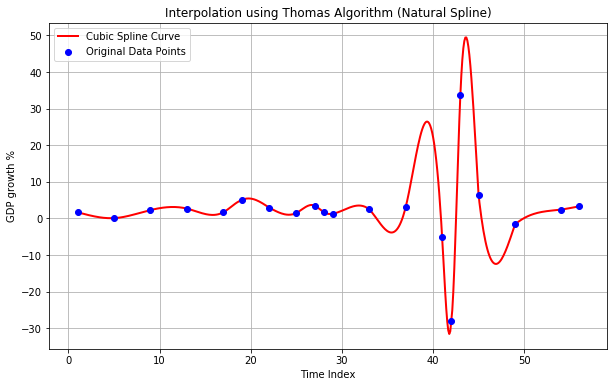

In [4]:
spline_start = time.perf_counter()
#Setup and Solve System
a, b, c, d = setup_tridiagonal_matrix(x_data, y_data)
M_internal = thomas_algorithm(a, b, c, d)

#Boundary Conditions
M = np.zeros(len(x_data))
M[1:-1] = M_internal

#values
x_plot_CS = np.linspace(min(x_data), max(x_data), 500)
y_plot_CS = evaluate_spline(x_data, y_data, M, x_plot_CS)

#Graphing
plt.figure(figsize=(10, 6))
plt.plot(x_plot_CS, y_plot_CS, label='Cubic Spline Curve', color='red', linewidth=2)

#Graphing
plt.scatter(x_data, y_data, color='blue', label='Original Data Points', zorder=5)

#Time analysis for later
spline_end = time.perf_counter()
spline_time = spline_end - spline_start

plt.title("Interpolation using Thomas Algorithm (Natural Spline)")
plt.xlabel("Time Index")
plt.ylabel("GDP growth %")
plt.legend()
plt.grid(True)
plt.show()

Part 1 explained:
There are 76 unknowns in this data set, namely from the 4 coefficients, A, B, C, and D in each connection between data points. These piecewise functions that connect the data points must intersect the data points and have a function value continuity. Thus, each internal knot must follow both first and second derivate continuity tests for their spline. The boundary conditions that define a natural spline are the endpoints of the overall data having their second derivative equal to zero.

Part 2

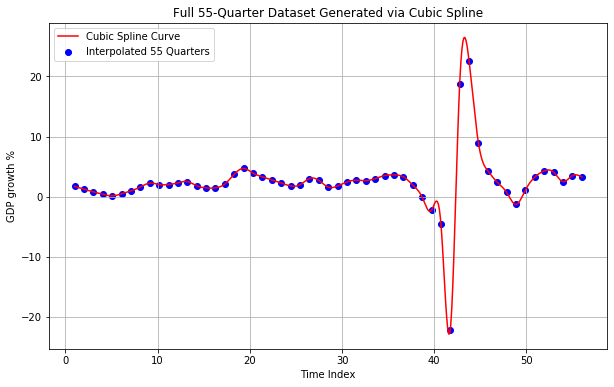

In [5]:
for i in range(2):
    x_full = np.linspace(x_data[0], x_data[-1], 55)
    y_full = np.array([evaluate_spline(x_data, y_data, M, xq) for xq in x_full])

    #Setup and Solve System
    a, b, c, d = setup_tridiagonal_matrix(x_full, y_full)
    M_internal = thomas_algorithm(a, b, c, d)

    #Boundary Conditions
    M = np.zeros(len(x_full))
    M[1:-1] = M_internal

    x_full_CS = np.linspace(x_full[0], x_full[-1], 500)
    y_full_CS = evaluate_spline(x_full, y_full, M, x_full_CS)

plt.figure(figsize=(10, 6))
plt.scatter(x_full, y_full, color='blue', label='Interpolated 55 Quarters')
plt.plot(x_full_CS, y_full_CS, label='Cubic Spline Curve', color='red')

plt.title("Full 55-Quarter Dataset Generated via Cubic Spline")
plt.xlabel("Time Index")
plt.ylabel("GDP growth %")
plt.legend()
plt.grid(True)
plt.show()

Part 2 explained:
The interpolant has less fluctuations, but it also seems less smooth overall. However, it does seem slightly more reasonable due to the decreased oscillations shown.

Part 3

Part 3 explained:
The Runge phenomenon is the oscillations of interpolated points at the edges of an interval in high-degree polynomial fittings. Interpolation via Cubic Spline reduces this error when facing extreme outliers in a data set, avoiding the oscillations but still facing overshoots from major outliers. A smoothing spline would be preferable here primarily due to how it reduces the influence of the outlier, reducing the local oscillations caused by extreme outliers, which would make the overall data interpolation better.

# Part B -- Polynomial & Least Squares Comparison

Part 1

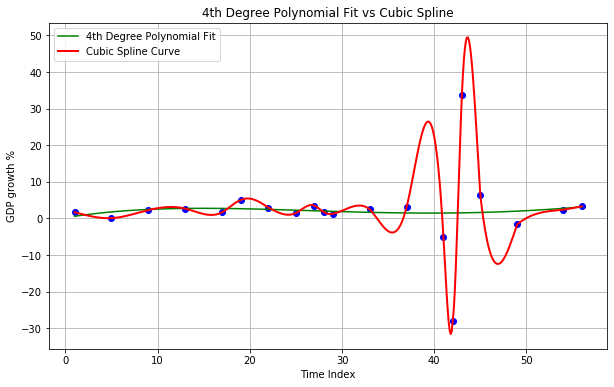

In [6]:
poly_start = time.perf_counter()

#Polynomial coeffcient calculation
coef = polynomial_fit(x_data, y_data, 4)
x_plot = np.linspace(1, 56, 100)
y_poly = sum(coef[i] * x_plot**i for i in range(len(coef)))

#plotting
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='blue')
plt.plot(x_plot, y_poly, color='green', label='4th Degree Polynomial Fit')

#Time measurement for later
poly_end = time.perf_counter()
poly_time = poly_end - poly_start

#Graphing
plt.plot(x_plot_CS, y_plot_CS, label='Cubic Spline Curve', color='red', linewidth=2)
plt.title("4th Degree Polynomial Fit vs Cubic Spline")
plt.xlabel("Time Index")
plt.ylabel("GDP growth %")
plt.legend()
plt.grid(True)
plt.show()

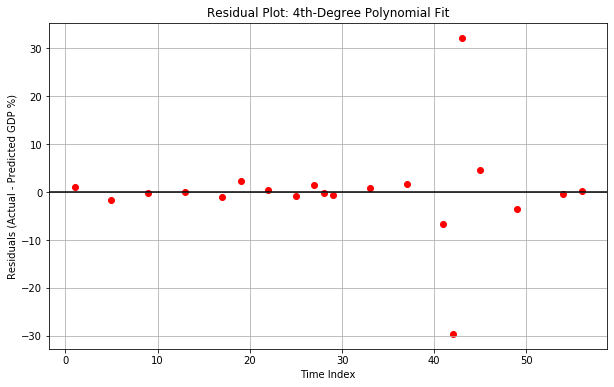

In [7]:
#Predicted y values
y_pred_poly = sum(coef[i] * x_data**i for i in range(len(coef)))

#Residuals
residuals_poly = y_data - y_pred_poly

#Plotting and graph
plt.figure(figsize=(10, 6))
plt.scatter(x_data, residuals_poly, color='red')
plt.axhline(0, color='black')
plt.title("Residual Plot: 4th-Degree Polynomial Fit")
plt.xlabel("Time Index")
plt.ylabel("Residuals (Actual - Predicted GDP %)")
plt.grid(True)
plt.show()

Part 1 explained:
The 4th degree polynomial fit better captures the overall trend and is not overly skewed too much by the outliers around 2020. Meanwhile, the Cubic Spline best reproduces each individual data point per quarter due to its exact nature. Approximation through polynomial fitting allows for the ability to make predictions for the future under the assumption of similar conditions, but interpolation through cubic spline fitting allows for an exact measurement of known data values, which works best for something that has a consistent fluctuation that follows a pattern or determining an exact point between known values. However, Cubic Spline does not allow for predictions of future data from data sets that have variances that do not follow a specific pattern, such as GDP. Conversely, Polynomial fitting struggles to get exact data points that matches with the given data set.

Part 2

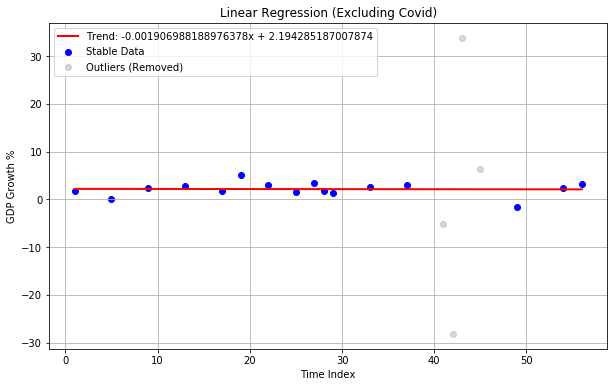

In [8]:
lsqr_start = time.perf_counter()

#Remove outliers
indices_to_remove = [13, 14, 15, 16] 
x_LSQR = np.delete(x_data, indices_to_remove)
y_LSQR = np.delete(y_data, indices_to_remove)

#Calculate LSQR
m, c = LSQR(x_LSQR, y_LSQR)

#Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x_LSQR, y_LSQR, color='blue', label='Stable Data')
plt.scatter(x_data[indices_to_remove], y_data[indices_to_remove], color='gray', alpha=0.3, label='Outliers (Removed)')
plt.plot(x_LSQR, m*x_LSQR + c, color='red', linewidth=2, label=f'Trend: {m}x + {c}')

#Time measurement for later
lsqr_end = time.perf_counter()
lsqr_time = lsqr_end - lsqr_start

#Graphing
plt.title("Linear Regression (Excluding Covid)")
plt.xlabel("Time Index")
plt.ylabel("GDP Growth %")
plt.legend()
plt.grid(True)
plt.show()

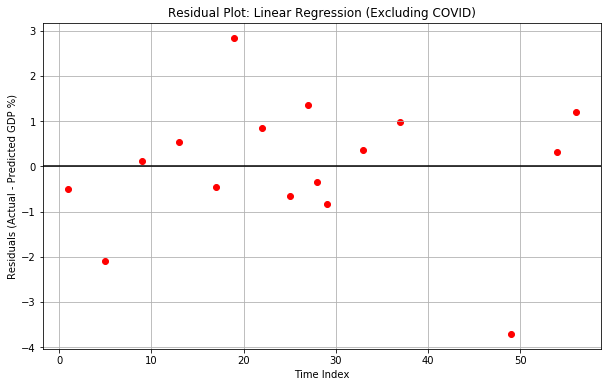

In [9]:
#Predicted y values
y_pred_linear = m * x_LSQR + c

#Residuals
residuals_linear = y_LSQR - y_pred_linear

#Plotting and graph
plt.figure(figsize=(10, 6))
plt.scatter(x_LSQR, residuals_linear, color='red')
plt.axhline(0, color='black')
plt.title("Residual Plot: Linear Regression (Excluding COVID)")
plt.xlabel("Time Index")
plt.ylabel("Residuals (Actual - Predicted GDP %)")
plt.grid(True)
plt.show()

Part 2 explained:
After removing the outliers from the COVID quarters, the slope of the overall data ends up being roughly -.0019. A linear trend does not make economic sense for this data primarily because GDP growth rates over time is cyclical in nature. GDP growth fluctuates around a mean rather than following a straight line forever, which a linear trend does not encapsulate. This is primarily shown by how the linear trend has greater residuals than the polynomial fitting. A linear trend requires the assumtion that an economy and its GDP are fluctuated only at a constant rate, which is not the case due to exponential growth and compounding factors in GDP growth as a whole.

# Part C -- Method Justification

Part 1

Part 1 explained:
For a policymaker who needs to estimate GDP growth for a quarter between two known data points, it would be best to use a Cubic Spline fitting. This is because a cubic spline offers a smoother result between the two, and it is more suited for interpolating points between two known data points. Cubic Spline provides more local control of outliers' effects in the data set instead of skewing the overall global trend like Polynomial fitting.

This is evident in the graphing in part B part 1, the Cubic spline better aligns with the data points, which allows for better interpolating and figuring out exact points between given data points. Meanwhile, the polynomial fitting fails to account for larger known shifts in the data due to it handling major local shifts poorly and it reflecting those outliers in the global trend instead. Thus, Cubic Spline is more suited for estimation of the GDP between 2 known points.

Part C addendum

The observed fitting times of the algorithms used for this case of GDP analysis
Cubic Spline fitting time: 0.02742304466664791
Polynomial fitting time: 0.0645087156444788
Least Squares fitting time: 0.0233036857098341
--------------------------------------------------------------------------------------


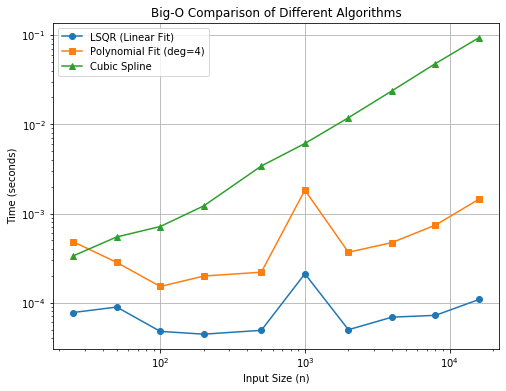

In [10]:
print("The observed fitting times of the algorithms used for this case of GDP analysis")
print(f"Cubic Spline fitting time: {spline_time}")
print(f"Polynomial fitting time: {poly_time}")
print(f"Least Squares fitting time: {lsqr_time}")
print("--------------------------------------------------------------------------------------")
#Data
def generate_data(n):
    x = np.linspace(0, 10, n)
    y = np.random.randn(n)
    return x, y

#Cubic spline simplified
def cubic_spline(x, y):
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    
    a = A[:-1]
    b = B.copy()
    c = C[1:]
    d = D.copy()
    
    M_internal = thomas_algorithm(a, b, c, d)
    
    M = np.zeros(len(x))
    M[1:-1] = M_internal
    
    return M

#Timing
def measure_time(func, *args):
    start = time.perf_counter()
    func(*args)
    end = time.perf_counter()
    return end - start

#Inputs
sizes = [25, 50, 100, 200, 500, 1000, 2000, 4000, 8000, 16000]

lsqr_times = []
poly_times = []
spline_times = []

for n in sizes:
    x, y = generate_data(n)

    #LSQR
    t_lsqr = measure_time(LSQR, x, y)
    lsqr_times.append(t_lsqr)

    #Polynomial fit
    t_poly = measure_time(polynomial_fit, x, y, 4)
    poly_times.append(t_poly)

    #Cubic spline
    t_spline = measure_time(cubic_spline, x, y)
    spline_times.append(t_spline)

#Plotting
plt.figure(figsize=(8, 6))

plt.loglog(sizes, lsqr_times, 'o-', label='LSQR (Linear Fit)')
plt.loglog(sizes, poly_times, 's-', label='Polynomial Fit (deg=4)')
plt.loglog(sizes, spline_times, '^-', label='Cubic Spline')

#Graphing
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.title('Big-O Comparison of Different Algorithms')
plt.legend()
plt.grid(True)

plt.show()

Part C addendum explained:
Big O notation is a way of measuring time and space complexity of an algorithms as the input size increases, which is most evident at much larger data sets. This allows for the understanding of the computational cost and complexity of different algorithms, which can influence how the choices of fitting algorithmn.

Normally, the computational cost to run a Cubic Spline is more than a Polynomial Fitting, which is more than a Least Squares Regression. This is due to the complexities of the algorithms, as measured through big-O as shown in the graph above. Additional steps result in more complexity and computational cost, which algorithms like Cubic Spline use more of. Meanwhile, simpler algorithms with less steps, like Least Squares Regression, have a lower complexity and computational cost. This is most clearly understood with the use of for loops as steps in each of the algorithms increasing their complexity. With Cubic Spline using 2, Polynomial fitting using 1, and Least Squares Regression using 0. However, this method is not truly accurate to what determines the complexity of an algorithm. In reality, the scale and types of operations, such as gaussian elimination, Thomas Algorithm, and matrix multiplication determine the complexity of the different algorithms. This is often correlated with the number of for loops used, but for loops do not provide a truly accurate representation.

However, despite this, for this data set, Cubic Spline actually is quicker than Polynomial fitting due to the data set being small, which can outweigh the complexity of the algorithm. The difference in time and computational costs between the methods in negligible and little benefit is achieved when using a less complex algorithm for a data set of this size. Since all methods use the same dataset, runtime comparisons are fair. Because the differences in computational cost are negligible at this scale, and cubic splines provide better interpolation, it remains the preferred method as stated earlier in Part C part 1.

# Conclusion
Overall the Cubic Spline method worked the best for interpolation because it matches exact data points accurately and avoids fluctuations from outliers when determining the data between known points. Meanwhile, the Polynomial Fitting method worked best for trend analysis because it provided a consistent trend to follow that allowed for the data to be affected by a variety of patterns and change overtime, which made it best for predicting where a trend might go. Each of methods used had their own strengths when it came to analyzing this data set. The least squares regression method allowed for prediction of where a trend might go under the constraints of the data not being exponential or compound in nature. The polynomial fitting method allowed for prediction of where a trend might go whilst allowing for shifts from exponential and compound factors. However, polynomial fitting was poor at interpolating data around outliers. The cubic spline method allowed for the best interpolation of data points due to how it intersected every point and followed a smooth path. However, due to how it intersects every point, it is poor at predicting where the trend of the data may go in the future.

Citing: used wikipedia to figure out what the Runge Phenomenom is. Additionally, used functions from class slides. I used AI tool, google Gemini, to check my code after being written to ensure it runs without numerical miscalcuations and accomplishes the task properly by asking it to review my code and understanding of each section.